In [5]:
# Cell 1: Load thu vien va du lieu Viet Nam
import pandas as pd
import numpy as np
import os
import torch
import warnings
warnings.filterwarnings("ignore")

# Duong dan den file du lieu VN
path_vn_main = "data/processed/VN_data/full_vietnam_monthly.csv"
path_vn_weather = "data/processed/VN_data/full_weather_vietnam_monthly.csv"

# Doc file
df_main = pd.read_csv(path_vn_main, sep=';')
df_weather = pd.read_csv(path_vn_weather) # Mac dinh la dau phay

print("Columns in main:", list(df_main.columns))
print("Columns in weather:", list(df_weather.columns))

display(df_main.head(3))
display(df_weather.head(3))


Columns in main: ['entity', 'date', 'series', 'is_aggregate_series', 'generation_twh', 'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'gas_price', 'castlecoal_price', 'castlecoal_vol']
Columns in weather: ['date', 'humidity_mean', 'precip_mean', 'solar_mean', 'temp_mean']


,entity,date,series,is_aggregate_series,generation_twh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,FDI_Disbursed_Monthly(bilionUSD),FDI_Registered_Monthly(bilionUSD),gas_price,castlecoal_price,castlecoal_vol
0,Viet Nam,1/1/2019,Coal,False,9.63,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
1,Viet Nam,1/1/2019,Gas,False,4.12,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K
2,Viet Nam,1/1/2019,Hydro,False,3.39,134.05,100.1,7700.0,59.27,1.55,1.907,65.28,99.0,1.14K


,date,humidity_mean,precip_mean,solar_mean,temp_mean
0,2019-01-01,78.634409,107.366667,401.016667,22.087097
1,2019-02-01,78.190476,30.700000,466.336667,24.680952
2,2019-03-01,78.408602,33.866667,522.160000,25.594624


In [6]:
# Cell 2: Merge du lieu va Tao casc feature can thiet
import copy

# Loai bo 'Total Generation' trong df_main truoc khi merge de tranh leak
if 'series' in df_main.columns:
    df_main['series'] = df_main['series'].astype(str).str.strip()
    df_main = df_main[~df_main['series'].str.casefold().eq('total generation')].copy()

df_vn = pd.merge(df_main, df_weather, on='date', how='left')

# Doi lai ten cho khop chuan cua file goc
df_vn = df_vn.rename(columns={
    'generation_twh': 'generation_TWh',
    'precip_mean': 'precipitation',
    'solar_mean': 'solar',
    'humidity_mean': 'humidity',
    'temp_mean': 'temperature'
})

# Loai bo cac cot lien quan den gia Gas va luong Gas do nhiem
cols_to_drop = ['gas_price', 'gas_vol']
if cols_to_drop:
    df_vn = df_vn.drop(columns=cols_to_drop, errors='ignore')
    print(f"Da loai bo cac cot Gas: {cols_to_drop}")

# Xu ly cac diem du lieu = 0 bang mot so epsilon cuc nho (1e-4) de ham noi suy/scale tot hon
if 'generation_TWh' in df_vn.columns:
    df_vn['generation_TWh'] = pd.to_numeric(df_vn['generation_TWh'], errors='coerce').fillna(0)
    df_vn['generation_TWh'] = df_vn['generation_TWh'].replace(0, 1e-4).clip(lower=1e-4)

# Dong bo Date va tao time_idx, month...
df_vn['date'] = pd.to_datetime(df_vn['date'])
df_vn = df_vn.sort_values(['entity', 'series', 'date']).reset_index(drop=True)

min_date = df_vn['date'].min()
df_vn['time_idx'] = ((df_vn['date'].dt.year - min_date.year) * 12 + (df_vn['date'].dt.month - min_date.month)).astype(int)
df_vn['month'] = df_vn['date'].dt.month.astype(str)
df_vn['month_sin'] = np.sin(2 * np.pi * df_vn['date'].dt.month / 12.0)
df_vn['month_cos'] = np.cos(2 * np.pi * df_vn['date'].dt.month / 12.0)

# Tao target lags va rolling cho generation_TWh
def create_lag_roll(group):
    g = group.copy()
    g = g.sort_values('date')
    for lag in [1, 3, 6, 12]:
        g[f'target_lag_{lag}'] = g['generation_TWh'].shift(lag)
    for window in [3, 6, 12]:
        g[f'target_roll_mean_{window}'] = g['generation_TWh'].shift(1).rolling(window, min_periods=1).mean()
        g[f'target_roll_std_{window}'] = g['generation_TWh'].shift(1).rolling(window, min_periods=1).std().fillna(0)
    return g

df_vn = df_vn.groupby(['entity', 'series'], group_keys=False).apply(create_lag_roll)

lag_roll_cols = [c for c in df_vn.columns if 'lag' in c or 'roll' in c]
for c in lag_roll_cols:
    df_vn[c] = df_vn[c].replace(0, 1e-4).clip(lower=1e-4)

# Xu ly missing values bang ffill / bfill theo group
cols_to_fill = ['precipitation', 'solar', 'humidity', 'temperature'] + \
               [c for c in df_vn.columns if 'target_lag' in c or 'target_roll' in c] + \
               ['IPI_Value', 'CPI_Value', 'GDP_VND_Trillion', 'Oil_Price', 'Oil_Change_Percent',
                'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)', 'castlecoal_price']

for c in cols_to_fill:
    if c in df_vn.columns:
        df_vn[c] = df_vn.groupby(['entity', 'series'])[c].transform(lambda x: x.ffill().bfill())
        df_vn[c] = df_vn[c].fillna(0)

# FIX format KMB for castlecoal_vol if exists
def to_float_series(s: pd.Series) -> pd.Series:
    txt = s.astype(str).str.strip().replace({"": np.nan, "nan": np.nan, "None": np.nan})
    suffix = txt.str.extract(r"([KMB])$", expand=False)
    base = pd.to_numeric(txt.str.replace(r"[KMB]$", "", regex=True), errors="coerce")
    mult = pd.Series(1.0, index=s.index, dtype="float32")
    mult[suffix == "K"] = 1e3
    mult[suffix == "M"] = 1e6
    mult[suffix == "B"] = 1e9
    return (base * mult).astype("float32")

if 'castlecoal_vol' in df_vn.columns:
    df_vn['castlecoal_vol'] = to_float_series(df_vn['castlecoal_vol'])
    df_vn['castlecoal_vol'] = df_vn['castlecoal_vol'].fillna(0)

print(f"Tong so records VN: {len(df_vn)}")
print(f"Cac loai nang luong: {df_vn['series'].unique()}")
display(df_vn.head(3))


Da loai bo cac cot Gas: ['gas_price', 'gas_vol']
Tong so records VN: 432
Cac loai nang luong: ['Coal' 'Gas' 'Hydro' 'Other fossil' 'Solar' 'Wind']


,entity,date,series,is_aggregate_series,generation_TWh,IPI_Value,CPI_Value,GDP_VND_Trillion,Oil_Price,FDI_Disbursed_Monthly(bilionUSD),...,target_lag_1,target_lag_3,target_lag_6,target_lag_12,target_roll_mean_3,target_roll_std_3,target_roll_mean_6,target_roll_std_6,target_roll_mean_12,target_roll_std_12
0,Viet Nam,2019-01-01,Coal,False,9.63,134.05,100.10,7700.0,59.27,1.55,...,9.63,9.63,9.63,9.63,9.630,0.000100,9.630,0.000100,9.630,0.000100
1,Viet Nam,2019-02-01,Coal,False,9.90,108.37,100.80,7700.0,64.13,1.03,...,9.63,9.63,9.63,9.63,9.630,0.000100,9.630,0.000100,9.630,0.000100
2,Viet Nam,2019-03-01,Coal,False,8.43,134.77,99.79,7700.0,66.41,1.54,...,9.90,9.63,9.63,9.63,9.765,0.190919,9.765,0.190919,9.765,0.190919


In [7]:
# Cell 3: Chuan bi Dataset va Dataloader cho VN
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer

max_encoder_length = 24
max_prediction_length = 6 # Su dung thiet lap giong Global LSTM model
batch_size = 16

# Kiem tra do dai
series_lengths = df_vn.groupby(['entity', 'series'])['time_idx'].nunique().reset_index(name='n_steps')
min_required_length = max_encoder_length + max_prediction_length
valid_groups = series_lengths.loc[series_lengths['n_steps'] >= min_required_length, ['entity', 'series']]
df_vn_valid = df_vn.merge(valid_groups, on=['entity', 'series'], how='inner').copy()

training_cutoff = df_vn_valid['time_idx'].max() - max_prediction_length

# !!! CRITICAL FOR LSTM !!!
# LSTM yeeu cau toan bo variables phai thuoc known_reals (co sat mat tren ca Encoder lan Decoder)
all_variables = [
    'time_idx', 'month_sin', 'month_cos',
    'precipitation', 'solar', 'humidity', 'temperature',
    'target_lag_1', 'target_lag_3', 'target_lag_6', 'target_lag_12',
    'target_roll_mean_3', 'target_roll_mean_6', 'target_roll_mean_12',
    'target_roll_std_3', 'target_roll_std_6', 'target_roll_std_12',
    'IPI_Value', 'CPI_Value', 'GDP_VND_Trillion',
    'Oil_Price', 'Oil_Change_Percent',
    'FDI_Disbursed_Monthly(bilionUSD)', 'FDI_Registered_Monthly(bilionUSD)',
    'castlecoal_price', 'castlecoal_vol'
]

known_reals = [c for c in all_variables if c in df_vn_valid.columns]
unknown_reals = ['generation_TWh']

# Dam bao float type cho real vars
for col in known_reals + unknown_reals:
    if df_vn_valid[col].dtype == object or df_vn_valid[col].dtype == str:
        df_vn_valid[col] = df_vn_valid[col].astype('float32')

training = TimeSeriesDataSet(
    df_vn_valid[df_vn_valid.time_idx <= training_cutoff],
    time_idx='time_idx',
    target='generation_TWh',
    group_ids=['entity', 'series'],
    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=['entity', 'series'],
    static_reals=[],
    time_varying_known_categoricals=[],
    time_varying_known_reals=known_reals,
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(groups=['entity', 'series'], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(training, df_vn_valid, predict=True, stop_randomization=True)

train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size * 2, num_workers=0)

print("Da tao xong DataLoaders mang kien truc LSTM rieng biet cho VN dataset")


Da tao xong DataLoaders mang kien truc LSTM rieng biet cho VN dataset


In [9]:
# Cell 4: Transfer Learning - Load pretrained weights va Dong bang (Freeze) LSTM
from pytorch_forecasting.models.rnn import RecurrentNetwork
from pytorch_forecasting.metrics import MAE

# 1. Khoi tao mo hinh LSTM MOI phu hop voi cau truc du lieu VN (co them features)
lstm_vn = RecurrentNetwork.from_dataset(
    training,
    cell_type="LSTM",
    hidden_size=32,      # Thong so base model
    rnn_layers=2,        # Thong so base model
    dropout=0.1,         # Thong so base model
    learning_rate=3e-4,  # GIAM LEARNING RATE (tu 1e-3 xuo'ng 3e-4) de transfer an toan
    loss=MAE(),
    reduce_on_plateau_patience=4,
)
print("Da khoi tao model LSTM moi theo kien truc Transfer Learning VN.")

# 2. Load transfer weights tu Global Model
checkpoint_path = "checkpoint\lstm_model.ckpt"
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Khong tim thay file {checkpoint_path}. Vui long chay Cell 6/7 trong Global LSTM de push qua!")

pretrained_dict = torch.load(checkpoint_path, map_location=lstm_vn.device, weights_only=False)['state_dict']
model_dict = lstm_vn.state_dict()

# Intersection match: chi lay cac parameter co dung ten va hinh dang y het
matched_dict = {k: v for k, v in pretrained_dict.items()
                if k in model_dict and v.shape == model_dict[k].shape}

model_dict.update(matched_dict)
lstm_vn.load_state_dict(model_dict)
print(f"Da transfer thanh cong {len(matched_dict)} / {len(model_dict)} tensors tu pretrained LSTM global model.")

# 3. Dong bang (Freeze) core LSTM rnn layer de chong "Hien tuong quen dot ngot" (Catastrophic Forgetting)
# Dieu nay giup LSTM tiep tuc su dung quy luat memory Toan cau ma no da hoc cac epoch truo'c
frozen_params = 0
unfrozen_params = 0

for name, param in lstm_vn.named_parameters():
    # Freeze toan bo parameters cua rnn module
    if "rnn" in name.lower():
        param.requires_grad = False
        frozen_params += param.numel()
    else:
        param.requires_grad = True
        unfrozen_params += param.numel()

print(f"---------------------------------------------------")
print(f"Tham so BI DONG BANG LSTM (Freezed): {frozen_params/1000:.1f} k")
print(f"Tham so FINETUNE (Unfreezed)       : {unfrozen_params/1000:.1f} k")
print(f"---------------------------------------------------")


Da khoi tao model LSTM moi theo kien truc Transfer Learning VN.
Da transfer thanh cong 9 / 12 tensors tu pretrained LSTM global model.
---------------------------------------------------
Tham so BI DONG BANG LSTM (Freezed): 17.3 k
Tham so FINETUNE (Unfreezed)       : 0.1 k
---------------------------------------------------


In [10]:
# Cell 5: Tien hanh Finetune (Train) model tren du lieu Viet Nam
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

pl.seed_everything(42)

early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=10, verbose=True, mode='min')
lr_logger = LearningRateMonitor()

trainer_vn = pl.Trainer(
    max_epochs=30, # Finetune
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    enable_model_summary=True,
    log_every_n_steps=10
)

# Bat daur Finetune
print("Bat dau Finetune...")
trainer_vn.fit(lstm_vn, train_dataloaders=train_loader, val_dataloaders=val_loader)


Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Bat dau Finetune...


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss             │ MAE            │      0 │ train │     0 │
│ 1 │ logging_metrics  │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings       │ MultiEmbedding │     25 │ train │     0 │
│ 3 │ rnn              │ LSTM           │ 17.3 K │ train │     0 │
│ 4 │ output_projector │ Linear         │     33 │ train │     0 │
└───┴──────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 58                                                                                               
Non-trainable params: 17.3 K                                                                                       
Total params: 17.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Metric val_loss improved by 0.003 >= min_delta = 0.0001. New best score: 1.143


Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 1.143


Metric val_loss improved by 0.004 >= min_delta = 0.0001. New best score: 1.139


Metric val_loss improved by 0.005 >= min_delta = 0.0001. New best score: 1.134


`Trainer.fit` stopped: `max_epochs=30` reached.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


---------- KET QUA HOAN CHINH (LSTM VIET NAM) ----------
MAE  : 1.1379
RMSE : 1.9805
MAPE : 31.1385%
SMAPE: 28.5123%
R^2  : 0.8196
---------------------------------------------------------


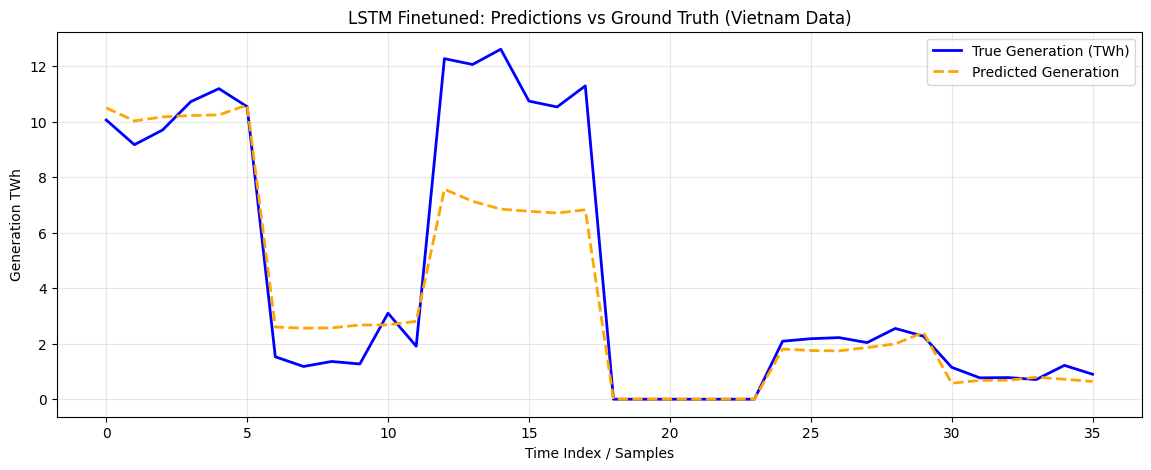

In [11]:
# Cell 6: Danh gia mo hinh sau khi Finetune (MAE, RMSE, SMAPE, MAPE, R2)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

def compute_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-4))) * 100

def compute_smape(y_true, y_pred):
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-4)) * 100

print("---------- KET QUA HOAN CHINH (LSTM VIET NAM) ----------")
preds = lstm_vn.predict(val_loader, mode="prediction")

y_true = []
for _, batch_y in val_loader:
    target = batch_y[0] if isinstance(batch_y, tuple) else batch_y
    y_true.append(target.detach().cpu().numpy())

y_true = np.concatenate([arr.flatten() for arr in y_true], axis=0)
y_pred = preds.detach().cpu().numpy().reshape(-1)

n = min(len(y_true), len(y_pred))
y_true = y_true[:n]
y_pred = y_pred[:n]

mask = np.isfinite(y_true) & np.isfinite(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = compute_mape(y_true, y_pred)
smape = compute_smape(y_true, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}%")
print(f"SMAPE: {smape:.4f}%")
print(f"R^2  : {r2:.4f}")
print("---------------------------------------------------------")

plt.figure(figsize=(14, 5))
plot_len = min(200, len(y_true))
plt.plot(y_true[-plot_len:], label="True Generation (TWh)", linewidth=2, color="blue")
plt.plot(y_pred[-plot_len:], label="Predicted Generation", linewidth=2, color="orange", linestyle="--")
plt.title("LSTM Finetuned: Predictions vs Ground Truth (Vietnam Data)")
plt.xlabel("Time Index / Samples")
plt.ylabel("Generation TWh")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
